# MAO-A Inhibitor Discovery- Computational Drug Discovery Pipeline

This notebook involves a complete computational drug discovery pipeline targeting 
Monoamine Oxidase A (MAO-A), which is a flavoenzyme involved in neurotransmitter degradation 
and a key therapeutic target for depression and anxiety.

The pipeline covers: data collection from ChEMBL → cleaning → pIC50 conversion → 
molecular descriptor extraction → machine learning → molecular docking → ADMET prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Collection

The ChEMBL database's Python interface is used to retrieve bioactivity data for MAO-A (CHEMBL1951). I only used IC50 values since they offer a consistent way to evaluate inhibitory potency. The initial query returns 1000 records from human MAO-A assays.

In [2]:
from chembl_webresource_client.new_client import new_client
activity = new_client.activity
MOA_client = activity.filter(target_chembl_id = 'CHEMBL1951').filter(type = 'IC50')

In [3]:
MOA_client

[{'action_type': None, 'activity_comment': None, 'activity_id': 184068, 'activity_properties': [], 'assay_chembl_id': 'CHEMBL715193', 'assay_description': 'Compound was tested for inhibition of monoamine oxidase-A (MAO-A).', 'assay_type': 'B', 'assay_variant_accession': None, 'assay_variant_mutation': None, 'bao_endpoint': 'BAO_0000190', 'bao_format': 'BAO_0000357', 'bao_label': 'single protein format', 'canonical_smiles': 'C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NCc3ccccc3)c(Br)c21', 'data_validity_comment': None, 'data_validity_description': None, 'document_chembl_id': 'CHEMBL1151505', 'document_journal': 'Bioorg Med Chem Lett', 'document_year': 1996, 'ligand_efficiency': {'bei': '12.34', 'le': '0.27', 'lle': '0.67', 'sei': '9.46'}, 'molecule_chembl_id': 'CHEMBL156630', 'molecule_pref_name': None, 'parent_molecule_chembl_id': 'CHEMBL156630', 'pchembl_value': '5.26', 'potential_duplicate': 0, 'qudt_units': 'http://www.openphacts.org/units/Nanomolar', 'record_id': 308504, 'relation': '=', 'src_id

In [4]:
df= pd.DataFrame(MOA_client[:1000])
df

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,184068,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,5.47
1,None,None,185442,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,1.36
2,None,None,189322,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,30.8
3,None,None,190494,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,22.5
4,None,None,191747,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,0.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,None,Inhibition < 50% @ 10 uM and thus dose-reponse...,7693345,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,Not Active,None,IC50,None,None,None,None
996,None,Inhibition < 50% @ 10 uM and thus dose-reponse...,7693480,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,Not Active,None,IC50,None,None,None,None
997,None,Inhibition < 50% @ 10 uM and thus dose-reponse...,7694225,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,Not Active,None,IC50,None,None,None,None
998,None,Inhibition < 50% @ 10 uM and thus dose-reponse...,7694277,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,Not Active,None,IC50,None,None,None,None


In [5]:
df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='object')

In [6]:
df.to_csv('MOA-A_activity.csv', index='False')

## 2. Data Cleaning & Filtering

The raw dataset contains missing values, non-numeric IC50 entries, and irrelevant columns. 
I retained only the essential columns (activity_id, canonical_smiles, type, value, class), 
drop rows with null values, and convert the IC50 column to numeric format. 
This yields 583 valid compounds for downstream analysis.

In [7]:
df2 = df.dropna(subset = 'value')
df2

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,184068,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,5.47
1,None,None,185442,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,1.36
2,None,None,189322,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,30.8
3,None,None,190494,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,22.5
4,None,None,191747,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,0.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,None,None,7642520,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,0.167
851,None,None,7655797,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,1.787
879,None,None,7663083,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,4.29
931,None,None,7676815,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Homo sapiens,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,2.52


In [8]:
df2['value'] = pd.to_numeric (df2['value'], errors = 'coerce')

/var/folders/kn/_2yfsq_10m972b_s7wq7ns_00000gn/T/ipykernel_63873/1971209154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['value'] = pd.to_numeric (df2['value'], errors = 'coerce')


## 3. Activity Classification

Compounds are classified into three activity categories based on their IC50 values (µM):
- **Active:** IC50 < 10 µM
- **Intermediate:** IC50 between 10 and 50 µM  
- **Inactive:** IC50 > 50 µM

This classification will be used as a label for any future classification tasks.

In [9]:
def classify (value):
    if value < 10:
        return 'Active'
    elif value > 50:
        return 'Inactive'
    else: return 'Intermediate'

df2['class'] = df2['value'].apply(classify)

/var/folders/kn/_2yfsq_10m972b_s7wq7ns_00000gn/T/ipykernel_63873/113488150.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['class'] = df2['value'].apply(classify)


In [10]:
df2

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value,class
0,None,None,184068,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,5.470,Active
1,None,None,185442,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,1.360,Active
2,None,None,189322,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,30.800,Intermediate
3,None,None,190494,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,22.500,Intermediate
4,None,None,191747,[],CHEMBL715193,Compound was tested for inhibition of monoamin...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,0.180,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,None,None,7642520,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,0.167,Active
851,None,None,7655797,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,1.787,Active
879,None,None,7663083,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,4.290,Active
931,None,None,7676815,[],CHEMBL1909169,DRUGMATRIX: Monoamine Oxidase MAO-A enzyme inh...,B,None,None,BAO_0000190,...,Amine oxidase [flavin-containing] A,9606,None,None,IC50,uM,UO_0000065,None,2.520,Active


In [11]:
selection = ['activity_id', 'canonical_smiles', 'type', 'value', 'class']
df3 = df2[selection]
df3

,activity_id,canonical_smiles,type,value,class
0,184068,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NCc3ccccc3)c(Br)c21,IC50,5.470,Active
1,185442,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NC)c(Cl)c21,IC50,1.360,Active
2,189322,CC(C)/N=C1/CCc2c1n(C)c1ccccc21,IC50,30.800,Intermediate
3,190494,C/N=C1/CCc2c1n(C)c1cc(Cl)c(OC(=O)NC)cc21,IC50,22.500,Intermediate
4,191747,COc1cc(Br)c2oc(C3CCNCC3)cc2c1,IC50,0.180,Active
...,...,...,...,...,...
798,7642520,CC(O)COC[C@H]1O[C@@H]2O[C@H]3[C@H](O)[C@@H](O)...,IC50,0.167,Active
851,7655797,N=C(N)N/N=C/c1c(Cl)cccc1Cl,IC50,1.787,Active
879,7663083,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=C[C@@H](O...,IC50,4.290,Active
931,7676815,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,IC50,2.520,Active


In [12]:
df3 = df3.dropna (subset = ['activity_id', 'canonical_smiles', 'type', 'value', 'class'])
df3

,activity_id,canonical_smiles,type,value,class
0,184068,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NCc3ccccc3)c(Br)c21,IC50,5.470,Active
1,185442,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NC)c(Cl)c21,IC50,1.360,Active
2,189322,CC(C)/N=C1/CCc2c1n(C)c1ccccc21,IC50,30.800,Intermediate
3,190494,C/N=C1/CCc2c1n(C)c1cc(Cl)c(OC(=O)NC)cc21,IC50,22.500,Intermediate
4,191747,COc1cc(Br)c2oc(C3CCNCC3)cc2c1,IC50,0.180,Active
...,...,...,...,...,...
798,7642520,CC(O)COC[C@H]1O[C@@H]2O[C@H]3[C@H](O)[C@@H](O)...,IC50,0.167,Active
851,7655797,N=C(N)N/N=C/c1c(Cl)cccc1Cl,IC50,1.787,Active
879,7663083,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=C[C@@H](O...,IC50,4.290,Active
931,7676815,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,IC50,2.520,Active


## 4. pIC50 Conversion

IC50 values are converted to pIC50 using the formula: `pIC50 = 6 - log10(IC50)`.
By creating a linear scale with higher values indicating greater potency, this modification improves the data's suitability for regression modelling.

In [13]:
df3['value'] = pd.to_numeric(df3['value'], errors='coerce')

def convert_ic50_to_pic50(ic50):
    if ic50 > 0:
        return 6 - np.log10(ic50)
    else:
        return np.nan

df3['pIC50'] = df3['value'].apply(convert_ic50_to_pic50)

In [14]:
df3

,activity_id,canonical_smiles,type,value,class,pIC50
0,184068,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NCc3ccccc3)c(Br)c21,IC50,5.470,Active,5.262013
1,185442,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NC)c(Cl)c21,IC50,1.360,Active,5.866461
2,189322,CC(C)/N=C1/CCc2c1n(C)c1ccccc21,IC50,30.800,Intermediate,4.511449
3,190494,C/N=C1/CCc2c1n(C)c1cc(Cl)c(OC(=O)NC)cc21,IC50,22.500,Intermediate,4.647817
4,191747,COc1cc(Br)c2oc(C3CCNCC3)cc2c1,IC50,0.180,Active,6.744727
...,...,...,...,...,...,...
798,7642520,CC(O)COC[C@H]1O[C@@H]2O[C@H]3[C@H](O)[C@@H](O)...,IC50,0.167,Active,6.777284
851,7655797,N=C(N)N/N=C/c1c(Cl)cccc1Cl,IC50,1.787,Active,5.747875
879,7663083,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=C[C@@H](O...,IC50,4.290,Active,5.367543
931,7676815,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,IC50,2.520,Active,5.598599


In [15]:
selection = ['activity_id', 'canonical_smiles', 'pIC50', 'class']
df3 = df3[selection]
df3

,activity_id,canonical_smiles,pIC50,class
0,184068,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NCc3ccccc3)c(Br)c21,5.262013,Active
1,185442,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NC)c(Cl)c21,5.866461,Active
2,189322,CC(C)/N=C1/CCc2c1n(C)c1ccccc21,4.511449,Intermediate
3,190494,C/N=C1/CCc2c1n(C)c1cc(Cl)c(OC(=O)NC)cc21,4.647817,Intermediate
4,191747,COc1cc(Br)c2oc(C3CCNCC3)cc2c1,6.744727,Active
...,...,...,...,...
798,7642520,CC(O)COC[C@H]1O[C@@H]2O[C@H]3[C@H](O)[C@@H](O)...,6.777284,Active
851,7655797,N=C(N)N/N=C/c1c(Cl)cccc1Cl,5.747875,Active
879,7663083,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=C[C@@H](O...,5.367543,Active
931,7676815,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,5.598599,Active


## 5. Molecular Descriptor Extraction

RDKit is used to compute physicochemical descriptors and Morgan fingerprints for each compound.

**Physicochemical descriptors:** MolWt, LogP, TPSA, HBD, HBA, Rotatable Bonds, Aromatic Rings, Ring Count.
These capture key drug-like properties relevant to bioavailability and CNS penetration.

**Morgan Fingerprints (ECFP4):** 2048-bit binary vectors encoding circular substructural 
features at radius=2. These capture local chemical environments and are widely used 
in QSAR modelling.

Invalid SMILES are removed, and all descriptors are computed on clean mol objects only.

In [16]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import rdFingerprintGenerator

In [17]:
df3 = df3.dropna(subset=['canonical_smiles'])

In [18]:
df3

,activity_id,canonical_smiles,pIC50,class
0,184068,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NCc3ccccc3)c(Br)c21,5.262013,Active
1,185442,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NC)c(Cl)c21,5.866461,Active
2,189322,CC(C)/N=C1/CCc2c1n(C)c1ccccc21,4.511449,Intermediate
3,190494,C/N=C1/CCc2c1n(C)c1cc(Cl)c(OC(=O)NC)cc21,4.647817,Intermediate
4,191747,COc1cc(Br)c2oc(C3CCNCC3)cc2c1,6.744727,Active
...,...,...,...,...
798,7642520,CC(O)COC[C@H]1O[C@@H]2O[C@H]3[C@H](O)[C@@H](O)...,6.777284,Active
851,7655797,N=C(N)N/N=C/c1c(Cl)cccc1Cl,5.747875,Active
879,7663083,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=C[C@@H](O...,5.367543,Active
931,7676815,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,5.598599,Active


In [19]:
df3['canonical_smiles'] = df3['canonical_smiles'].astype(str)

In [20]:
valid_molecules = []
invalid_smiles = []

for smiles in df3['canonical_smiles']:
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) else None
    if mol:
        valid_molecules.append(mol)
    else:
        invalid_smiles.append(smiles)

In [21]:
print(f"Invalid SMILES count: {len(invalid_smiles)}")

Invalid SMILES count: 0


In [22]:
mol = Chem.MolFromSmiles(smiles)

In [23]:
Descriptors.MolWt(mol)

333.4530000000002

In [24]:
df3['mol'] = df3['canonical_smiles'].apply(Chem.MolFromSmiles)
df_clean = df3.dropna(subset=['mol'])  

molecules = df_clean['mol'].tolist()

In [25]:
def get_descriptors(mol):
    return {
        'MolWt':            Descriptors.MolWt(mol),
        'LogP':             Descriptors.MolLogP(mol),
        'TPSA':             rdMolDescriptors.CalcTPSA(mol),
        'HBD':              rdMolDescriptors.CalcNumHBD(mol),
        'HBA':              rdMolDescriptors.CalcNumHBA(mol),
        'RotatableBonds':   rdMolDescriptors.CalcNumRotatableBonds(mol),
        'AromaticRings':    rdMolDescriptors.CalcNumAromaticRings(mol),
        'RingCount':        rdMolDescriptors.CalcNumRings(mol),
    }

desc_df = pd.DataFrame(
    [get_descriptors(mol) for mol in df_clean['mol']],
    index=df_clean.index
)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

morgan_fps = df_clean['mol'].apply(morgan_gen.GetFingerprintAsNumPy)

morgan_df = pd.DataFrame(
    list(morgan_fps),
    columns=[f'Morgan_{i}' for i in range(2048)],
    index=df_clean.index
)

df_final = pd.concat([df_clean[['canonical_smiles', 'pIC50', 'class']], desc_df, morgan_df], axis=1)
df_final

,canonical_smiles,pIC50,class,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,AromaticRings,...,Morgan_2038,Morgan_2039,Morgan_2040,Morgan_2041,Morgan_2042,Morgan_2043,Morgan_2044,Morgan_2045,Morgan_2046,Morgan_2047
0,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NCc3ccccc3)c(Br)c21,5.262013,Active,426.314,4.59450,55.62,1,3,3,3,...,0,0,0,0,0,0,0,0,0,0
1,C/N=C1/CCc2c1n(C)c1ccc(OC(=O)NC)c(Cl)c21,5.866461,Active,305.765,2.91500,55.62,1,3,1,2,...,0,0,0,0,0,0,0,0,0,0
2,CC(C)/N=C1/CCc2c1n(C)c1ccccc21,4.511449,Intermediate,226.323,3.32200,17.29,0,1,1,2,...,0,0,0,0,0,0,0,0,0,0
3,C/N=C1/CCc2c1n(C)c1cc(Cl)c(OC(=O)NC)cc21,4.647817,Intermediate,305.765,2.91500,55.62,1,3,1,2,...,0,0,0,0,0,0,0,0,0,0
4,COc1cc(Br)c2oc(C3CCNCC3)cc2c1,6.744727,Active,310.191,3.67090,34.40,1,3,2,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,CC(O)COC[C@H]1O[C@@H]2O[C@H]3[C@H](O)[C@@H](O)...,6.777284,Active,1541.547,-12.39490,618.66,21,42,28,0,...,0,0,0,0,0,0,0,0,0,0
851,N=C(N)N/N=C/c1c(Cl)cccc1Cl,5.747875,Active,231.086,1.81037,74.26,3,2,2,1,...,0,0,0,0,0,0,0,0,0,0
879,C#C[C@]1(OC(C)=O)CC[C@H]2[C@@H]3CCC4=C[C@@H](O...,5.367543,Active,384.516,4.42590,52.60,0,4,2,0,...,0,0,0,0,0,0,0,0,0,0
931,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,5.598599,Active,270.240,2.57680,90.90,3,5,1,3,...,0,0,1,0,0,0,0,0,0,0


# Machine Learning-Based Bioactivity Prediction

Molecular descriptors and Morgan fingerprints were generated using RDKit to numerically represent the chemical compounds. Experimental IC50 values from ChEMBL were converted to pIC50 values for use as the target variable.

A Random Forest Regressor model was trained using the combined feature set to predict compound bioactivity against MAO-A. The model predictions were used to identify top candidate molecules for subsequent molecular docking studies.                                         

**Input features:** 2056 columns (8 physicochemical descriptors + 2048 Morgan fingerprint bits)  
**Target:** experimental pIC50  
**Split:** 80% training, 20% test

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [27]:
y = df_final['pIC50']
x = df_final.drop(columns = ['pIC50'])

In [28]:
print(x.shape)
print(y.shape)
print(x.dtypes.value_counts())

(583, 2058)
(583,)
uint8      2048
int64         5
float64       3
object        2
Name: count, dtype: int64


In [29]:
x = x.select_dtypes(include=['number'])

In [30]:
print(x.dtypes.value_counts())

uint8      2048
int64         5
float64       3
Name: count, dtype: int64


In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [32]:
model = RandomForestRegressor()
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred = model.predict(x_test)
print(r2_score(y_test,y_pred))

0.7114172832619996


In [34]:
lr = LinearRegression()
lr.fit(x_train, y_train)

print("LR R2:", r2_score(y_test, lr.predict(x_test)))

LR R2: 0.36075273142371456


In [35]:
df_final['predicted_pIC50'] = model.predict(x)

In [36]:
df_clean = pd.concat([df_clean, desc_df], axis=1)

In [37]:
print("Train R²:", r2_score(y_train, model.predict(x_train)))
print("Test R²:",  r2_score(y_test,  model.predict(x_test)))

Train R²: 0.9001298580757535
Test R²: 0.7114172832619996


In [40]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, x, y, cv=5, scoring='r2')
print("CV R² scores:", cv_scores)
print("Mean R²:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV R² scores: [-0.14117332 -0.02936908 -1.01241051 -0.17130337 -0.16751213]
Mean R²: -0.3043536792389835
Std Dev: 0.3577755798247479


**Note on Results:** Cross-validation revealed significant overfitting (mean CV R² = -0.26), likely due to the high dimensionality of Morgan fingerprints (2048 bits) relative to the dataset size (~583 compounds). Future work could address this through feature selection or dimensionality reduction (e.g., PCA) before modelling. For the purposes of this project, top candidates were selected based on experimental pIC50 values rather than model predictions.

## 7. Candidate Selection & Lipinski Filtering

The top 20 compounds are selected by highest experimental pIC50. These are then filtered 
using Lipinski's Rule of Five to ensure oral drug-likeness:
- Molecular Weight ≤ 500 Da
- LogP ≤ 5
- Hydrogen Bond Donors ≤ 5
- Hydrogen Bond Acceptors ≤ 10

All 20 top compounds pass the filter. 3D conformers are generated using RDKit's ETKDGv3 
algorithm with MMFF energy minimisation, and exported as an SDF file for docking.

In [38]:
top_df_final = df_clean.sort_values(by='pIC50', ascending=False).head(20)

lipinski_filter = (
    (top_df_final['MolWt'] <= 500) &
    (top_df_final['LogP'] <= 5) &
    (top_df_final['HBD'] <= 5) &
    (top_df_final['HBA'] <= 10)
)
top_lipinski = top_df_final[lipinski_filter]
print(f"Molecules passing Lipinski: {len(top_lipinski)}")

Molecules passing Lipinski: 20


In [39]:
top_df_final.to_csv("top_molecules.csv", index=False)

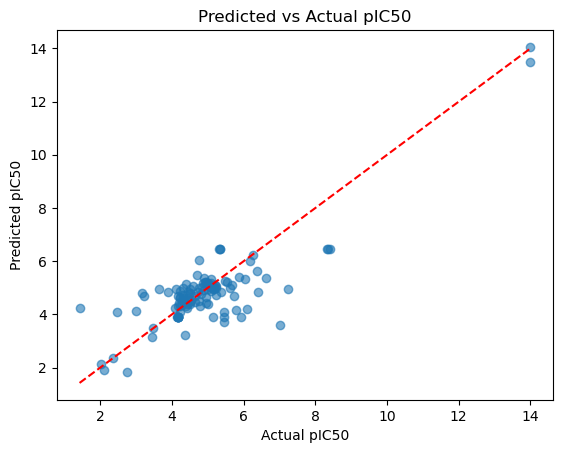

In [41]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predicted vs Actual pIC50")
plt.show()

In [42]:
writer = Chem.SDWriter("top_molecules_3d.sdf")

for idx, row in top_lipinski.iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    mol = Chem.AddHs(mol)                          # add hydrogens
    AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())  # generate 3D coords
    AllChem.MMFFOptimizeMolecule(mol)              # energy minimise
    mol.SetProp("_Name", str(idx))                 # label with index
    mol.SetProp("pIC50", str(row['pIC50']))         # keep pIC50 as metadata
    writer.write(mol)

writer.close()

## 8. Molecular Docking Results

Docking was performed using AutoDock Vina v1.2.7 against the human MAO-A crystal structure 
(PDB: 2Z5X, resolution 2.2 Å). The protein was prepared in PyMOL (water and co-crystallised 
ligand removed) and converted to PDBQT format using Open Babel.

**Binding site:** centred on the harmine co-crystallisation site [34.804, 28.304, -20.001]  
**Grid box:** 20 × 20 × 20 Å | **Exhaustiveness:** 8

Results are ranked by best binding affinity (kcal/mol). More negative values indicate 
stronger predicted binding. The known MAO-A inhibitor harmine has an affinity of ~-8 to -9 kcal/mol,
providing a useful reference point.

In [50]:
import os
import re

results_dir = "/Users/sanika/Desktop/docking_results"
results = []

for i in range(1, 21):
    filepath = os.path.join(results_dir, f"ligand{i}_out.pdbqt")
    
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            content = f.read()
        
        # Extract affinity scores
        affinities = re.findall(r'REMARK VINA RESULT:\s+([-\d.]+)', content)
        
        if affinities:
            best_affinity = float(affinities[0])  
            results.append({
                'Ligand': f'ligand{i}',
                'Best_Affinity_kcal_mol': best_affinity,
                'All_Modes': [float(a) for a in affinities]
            })

df_results = pd.DataFrame(results)[['Ligand', 'Best_Affinity_kcal_mol']]
df_results = df_results.sort_values('Best_Affinity_kcal_mol').reset_index(drop=True)
df_results['Rank'] = df_results.index + 1

print(df_results)

df_results.to_csv("/Users/sanika/Desktop/Python/MOA-A project/docking_results.csv", index=False)
print("\nSaved to docking_results.csv!")

      Ligand  Best_Affinity_kcal_mol  Rank
0    ligand5                 -10.728     1
1    ligand7                 -10.676     2
2    ligand4                  -9.880     3
3   ligand10                  -9.716     4
4    ligand1                  -9.673     5
5   ligand12                  -9.215     6
6    ligand8                  -9.080     7
7    ligand6                  -9.075     8
8   ligand11                  -8.976     9
9    ligand9                  -8.865    10
10   ligand3                  -8.864    11
11   ligand2                  -8.421    12
12  ligand20                  -7.644    13
13  ligand18                  -7.218    14
14  ligand15                  -7.202    15
15  ligand16                  -7.182    16
16  ligand14                  -7.164    17
17  ligand17                  -7.160    18
18  ligand13                  -7.156    19
19  ligand19                  -7.132    20

Saved to docking_results.csv!


In [49]:
df_results['Ligand_num'] = df_results['Ligand'].str.extract('(\d+)').astype(int)
top_df_final = top_df_final.reset_index(drop=True)
top_df_final['Ligand_num'] = top_df_final.index + 1

df_final_results = df_results.merge(
    top_df_final[['Ligand_num', 'canonical_smiles', 'pIC50']],
    on='Ligand_num'
).drop(columns='Ligand_num')

df_final_results.to_csv(
    "/Users/sanika/Desktop/Python/MOA-A project/docking_results_final.csv", 
    index=False
)
print(df_final_results)

      Ligand  Best_Affinity_kcal_mol  Rank                             canonical_smiles      pIC50
0    ligand5                 -10.728     1      COc1ccc(C2CC(c3ccc(O)cc3)=NN2C(C)=O)cc1  14.045757
1    ligand7                 -10.676     2      CC(=O)N1N=C(c2ccc(O)cc2O)CC1c1ccc(C)cc1  14.045757
2    ligand4                  -9.880     3        COc1ccccc1C1CC(c2ccc(O)cc2)=NN1C(C)=O  14.055517
3   ligand10                  -9.716     4      CC(=O)N1N=C(c2ccc(O)cc2)CC1c1cccc(Cl)c1  14.000000
4    ligand1                  -9.673     5       CC(=O)N1N=C(c2ccc(O)cc2)CC1c1cccc(C)c1  14.096910
5   ligand12                  -9.215     6       CC(=O)N1N=C(c2ccc(O)cc2)CC1c1ccc(C)cc1  13.000000
6    ligand8                  -9.080     7  COc1ccc(C2CC(c3ccc(O)cc3)=NN2C(C)=O)c(OC)c1  14.000000
7    ligand6                  -9.075     8     COc1ccc(C2CC(c3ccc(O)cc3O)=NN2C(C)=O)cc1  14.045757
8   ligand11                  -8.976     9      CC(=O)N1N=C(c2ccc(O)cc2)CC1c1ccc(Cl)cc1  13.000000
9    ligan

In [48]:
pd.set_option('display.max_colwidth', 50)  
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 10)

df_final_results

,Ligand,Best_Affinity_kcal_mol,Rank,canonical_smiles,pIC50
0,ligand5,-10.728,1,COc1ccc(C2CC(c3ccc(O)cc3)=NN2C(C)=O)cc1,14.045757
1,ligand7,-10.676,2,CC(=O)N1N=C(c2ccc(O)cc2O)CC1c1ccc(C)cc1,14.045757
2,ligand4,-9.880,3,COc1ccccc1C1CC(c2ccc(O)cc2)=NN1C(C)=O,14.055517
3,ligand10,-9.716,4,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1cccc(Cl)c1,14.000000
4,ligand1,-9.673,5,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1cccc(C)c1,14.096910
5,ligand12,-9.215,6,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1ccc(C)cc1,13.000000
6,ligand8,-9.080,7,COc1ccc(C2CC(c3ccc(O)cc3)=NN2C(C)=O)c(OC)c1,14.000000
7,ligand6,-9.075,8,COc1ccc(C2CC(c3ccc(O)cc3O)=NN2C(C)=O)cc1,14.045757
8,ligand11,-8.976,9,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1ccc(Cl)cc1,13.000000
9,ligand9,-8.865,10,CC(=O)N1N=C(c2ccc(O)cc2O)CC1c1ccc(Cl)cc1,14.000000


In [46]:
from IPython.display import display
display(df_final_results.style.background_gradient(subset=['Best_Affinity_kcal_mol'], cmap='RdYlGn'))

,Ligand,Best_Affinity_kcal_mol,Rank,canonical_smiles,pIC50
0,ligand5,-10.728000,1,COc1ccc(C2CC(c3ccc(O)cc3)=NN2C(C)=O)cc1,14.045757
1,ligand7,-10.676000,2,CC(=O)N1N=C(c2ccc(O)cc2O)CC1c1ccc(C)cc1,14.045757
2,ligand4,-9.880000,3,COc1ccccc1C1CC(c2ccc(O)cc2)=NN1C(C)=O,14.055517
3,ligand10,-9.716000,4,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1cccc(Cl)c1,14.000000
4,ligand1,-9.673000,5,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1cccc(C)c1,14.096910
5,ligand12,-9.215000,6,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1ccc(C)cc1,13.000000
6,ligand8,-9.080000,7,COc1ccc(C2CC(c3ccc(O)cc3)=NN2C(C)=O)c(OC)c1,14.000000
7,ligand6,-9.075000,8,COc1ccc(C2CC(c3ccc(O)cc3O)=NN2C(C)=O)cc1,14.045757
8,ligand11,-8.976000,9,CC(=O)N1N=C(c2ccc(O)cc2)CC1c1ccc(Cl)cc1,13.000000
9,ligand9,-8.865000,10,CC(=O)N1N=C(c2ccc(O)cc2O)CC1c1ccc(Cl)cc1,14.000000


## 9. ADMET Prediction

ADMET (Absorption, Distribution, Metabolism, Excretion, Toxicity) properties are estimated 
for all top candidates using RDKit-derived descriptors and established pharmacological cutoffs.

- **Lipinski Rule of Five** — oral bioavailability filter  
- **GI Absorption** — estimated from TPSA < 140 Å² and MW < 500  
- **BBB Penetration** — critical for CNS targets; estimated from TPSA < 90 Å² and MW < 400  
- **Bioavailability** — LogP ≤ 5, MW ≤ 500, RotBonds ≤ 10

Note: These are rule-based estimates. For publication-level work, detailed predictions 
(hERG toxicity, CYP inhibition, mutagenicity) should be obtained via SwissADME or pkCSM.

In [47]:
def predict_admet(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = rdMolDescriptors.CalcNumHBD(mol)
    hba = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    rotbonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
    
    lipinski = all([mw <= 500, logp <= 5, hbd <= 5, hba <= 10])
    
    bbb = tpsa < 90 and mw < 400
    
    gi_absorption = tpsa < 140 and mw < 500
    
    bioavailability = logp <= 5 and mw <= 500 and rotbonds <= 10
    
    return {
        'MolWt': round(mw, 2),
        'LogP': round(logp, 2),
        'HBD': hbd,
        'HBA': hba,
        'TPSA': round(tpsa, 2),
        'RotBonds': rotbonds,
        'Lipinski': '✅' if lipinski else '❌',
        'GI_Absorption': '✅' if gi_absorption else '❌',
        'BBB_Penetration': '✅' if bbb else '❌',
        'Bioavailability': '✅' if bioavailability else '❌'
    }

admet_results = df_final_results['canonical_smiles'].apply(predict_admet)
df_admet = pd.DataFrame(admet_results.tolist())
df_admet.insert(0, 'Ligand', df_final_results['Ligand'].values)
df_admet.insert(1, 'Affinity', df_final_results['Best_Affinity_kcal_mol'].values)
df_admet.insert(2, 'pIC50', df_final_results['pIC50'].values)

display(df_admet)

df_admet.to_csv("/Users/sanika/Desktop/Python/MOA-A project/admet_results.csv", index=False)
print("Saved admet_results.csv!")

,Ligand,Affinity,pIC50,MolWt,LogP,...,RotBonds,Lipinski,GI_Absorption,BBB_Penetration,Bioavailability
0,ligand5,-10.728,14.045757,310.35,3.10,...,3,✅,✅,✅,✅
1,ligand7,-10.676,14.045757,310.35,3.10,...,2,✅,✅,✅,✅
2,ligand4,-9.880,14.055517,310.35,3.10,...,3,✅,✅,✅,✅
3,ligand10,-9.716,14.000000,314.77,3.74,...,2,✅,✅,✅,✅
4,ligand1,-9.673,14.096910,294.35,3.40,...,2,✅,✅,✅,✅
5,ligand12,-9.215,13.000000,294.35,3.40,...,2,✅,✅,✅,✅
6,ligand8,-9.080,14.000000,340.38,3.11,...,4,✅,✅,✅,✅
7,ligand6,-9.075,14.045757,326.35,2.80,...,3,✅,✅,✅,✅
8,ligand11,-8.976,13.000000,314.77,3.74,...,2,✅,✅,✅,✅
9,ligand9,-8.865,14.000000,330.77,3.45,...,2,✅,✅,✅,✅


Saved admet_results.csv!
